# Building the Transformer Encoder

Packages that are being used in this notebook:

In [1]:
from importlib.metadata import version

print("torch version:", version("torch"))
print("matplotlib version:", version("matplotlib"))
print("numpy version:", version("numpy"))

torch version: 1.11.0
matplotlib version: 3.10.3
numpy version: 1.26.4


In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(123)

- In the previous notebooks, we covered **tokenization & embeddings** (Chapter 1) and **attention mechanisms** (Chapter 2)
- Now we assemble these pieces into the **Transformer Encoder** — the left half of the original Transformer architecture
- The encoder is used in models like **BERT**, **RoBERTa**, and the encoder side of sequence-to-sequence models like **T5**

## Overview: What is the Transformer Encoder?

- The Transformer Encoder processes an input sequence and produces **contextualized representations** for each token
- Unlike the decoder (used in GPT), the encoder uses **bidirectional** attention — every token can attend to every other token
- The encoder is a stack of identical layers, each containing two sub-layers:
  1. **Multi-Head Self-Attention**
  2. **Position-wise Feed-Forward Network**
- Each sub-layer has a **residual connection** and **layer normalization**

Let's visualize the high-level architecture:

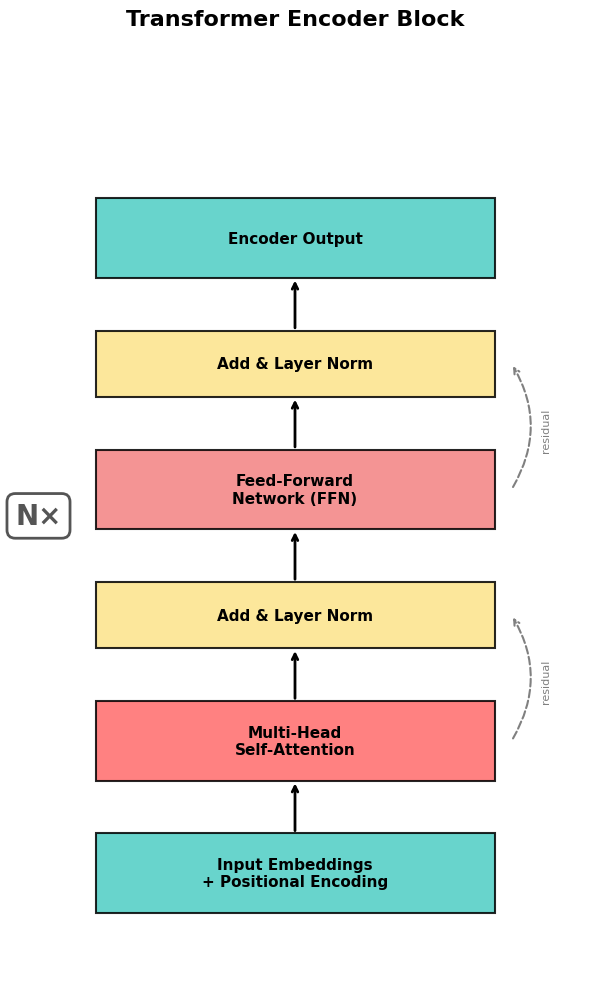

In [3]:
fig, ax = plt.subplots(figsize=(6, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 14)
ax.axis('off')
ax.set_title('Transformer Encoder Block', fontsize=16, fontweight='bold', pad=20)

# Colors
colors = {
    'input': '#4ECDC4',
    'attention': '#FF6B6B',
    'norm': '#95E1D3',
    'ffn': '#F38181',
    'add': '#FCE38A',
    'output': '#4ECDC4'
}

# Draw blocks bottom to top
blocks = [
    (1.5, 1.0, 7, 1.2, 'Input Embeddings\n+ Positional Encoding', colors['input']),
    (1.5, 3.0, 7, 1.2, 'Multi-Head\nSelf-Attention', colors['attention']),
    (1.5, 5.0, 7, 1.0, 'Add & Layer Norm', colors['add']),
    (1.5, 6.8, 7, 1.2, 'Feed-Forward\nNetwork (FFN)', colors['ffn']),
    (1.5, 8.8, 7, 1.0, 'Add & Layer Norm', colors['add']),
    (1.5, 10.6, 7, 1.2, 'Encoder Output', colors['output']),
]

for x, y, w, h, label, color in blocks:
    rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor='black', linewidth=1.5, alpha=0.85)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=11, fontweight='bold')

# Arrows
arrow_props = dict(arrowstyle='->', color='black', lw=2)
arrow_x = 5.0
arrows = [(2.2, 3.0), (4.2, 5.0), (6.0, 6.8), (8.0, 8.8), (9.8, 10.6)]
for y_start, y_end in arrows:
    ax.annotate('', xy=(arrow_x, y_end), xytext=(arrow_x, y_start),
                arrowprops=arrow_props)

# Residual connection arrows (curved)
for res_start, res_end in [(3.0, 5.0), (6.8, 8.8)]:
    ax.annotate('', xy=(8.8, res_end + 0.5), xytext=(8.8, res_start + 0.6),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, 
                               connectionstyle='arc3,rad=0.3', linestyle='--'))
    ax.text(9.4, (res_start + res_end)/2 + 0.5, 'residual', fontsize=8, color='gray', 
            rotation=90, ha='center', va='center')

# Nx label
ax.text(0.5, 7.0, 'N×', fontsize=20, fontweight='bold', color='#555',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#555', linewidth=2))

plt.tight_layout()
plt.show()

- We will build each component **from scratch**, step by step
- At the end, we will stack them together into a complete **Transformer Encoder**

---

## 1. Input Embeddings + Positional Encoding (Recap)

- In Chapter 1, we learned that tokens are first converted to dense vectors via an **embedding layer**
- Since the Transformer has no recurrence, we add **positional information** so the model knows the order of tokens
- The original Transformer paper ("Attention Is All You Need") uses **sinusoidal positional encodings**
- Here, we'll implement the sinusoidal version to stay true to the original encoder design

### 1.1 Sinusoidal Positional Encoding

- The positional encoding uses sine and cosine functions of different frequencies:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

- Where `pos` is the position and `i` is the dimension index
- Each dimension of the positional encoding corresponds to a sinusoid with a different wavelength

In [4]:
class SinusoidalPositionalEncoding(nn.Module):
    """Sinusoidal positional encoding from 'Attention Is All You Need'."""
    
    def __init__(self, d_model, max_len=512):
        super().__init__()
        
        pe = torch.zeros(max_len, d_model)  # (max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # (max_len, 1)
        
        # Compute the div_term: 10000^(2i/d_model)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
        )  # (d_model/2,)
        
        pe[:, 0::2] = torch.sin(position * div_term)  # even indices
        pe[:, 1::2] = torch.cos(position * div_term)  # odd indices
        
        # Register as buffer (not a trainable parameter)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)
    
    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        return x + self.pe[:, :x.size(1), :]

- Let's visualize the sinusoidal patterns to build intuition
- Each position gets a unique encoding pattern; nearby positions have similar patterns

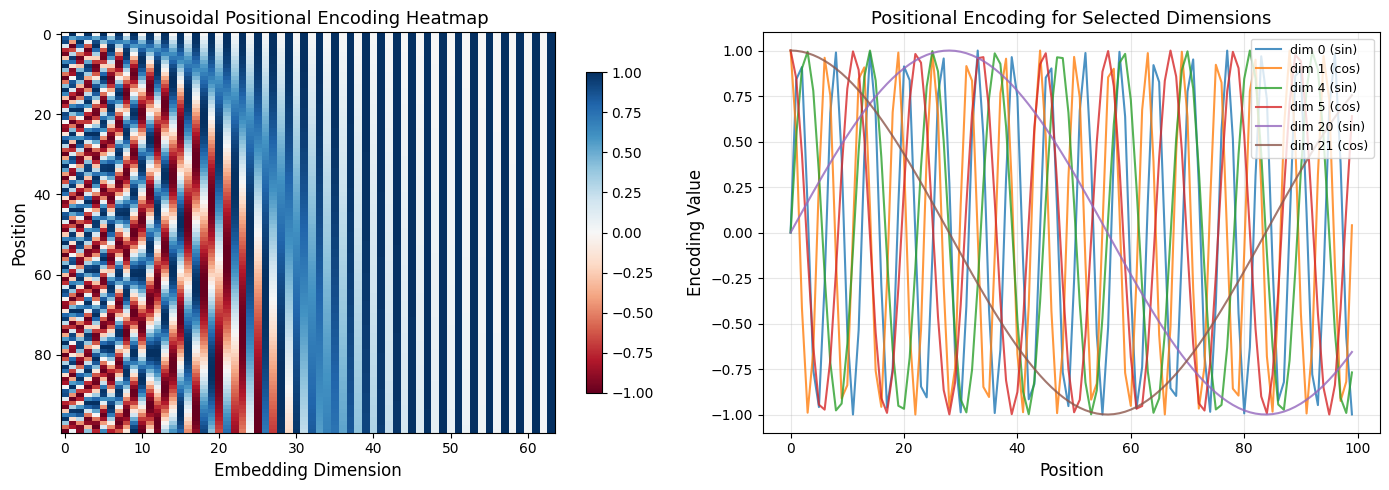

In [5]:
d_model = 64
max_len = 100

pos_enc = SinusoidalPositionalEncoding(d_model, max_len)
pe_values = pos_enc.pe.squeeze(0).numpy()  # (max_len, d_model)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Heatmap of positional encodings
im = axes[0].imshow(pe_values, cmap='RdBu', aspect='auto', interpolation='nearest')
axes[0].set_xlabel('Embedding Dimension', fontsize=12)
axes[0].set_ylabel('Position', fontsize=12)
axes[0].set_title('Sinusoidal Positional Encoding Heatmap', fontsize=13)
plt.colorbar(im, ax=axes[0], shrink=0.8)

# Right: Individual sinusoidal curves for selected dimensions
positions = np.arange(max_len)
for dim in [0, 1, 4, 5, 20, 21]:
    label = f'dim {dim} ({"sin" if dim % 2 == 0 else "cos"})'
    axes[1].plot(positions, pe_values[:, dim], label=label, alpha=0.8)

axes[1].set_xlabel('Position', fontsize=12)
axes[1].set_ylabel('Encoding Value', fontsize=12)
axes[1].set_title('Positional Encoding for Selected Dimensions', fontsize=13)
axes[1].legend(fontsize=9, loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- **Left**: The heatmap shows that each position has a unique pattern across dimensions
- **Right**: Lower dimensions oscillate fast (high frequency), higher dimensions oscillate slowly (low frequency)
- This means nearby positions share similar encodings, while distant positions differ — exactly what we want!

### 1.2 Token Embedding + Positional Encoding Combined

In [6]:
# Let's create a small example
vocab_size = 1000
d_model = 64
seq_len = 6
batch_size = 2

# Token embedding layer
token_embedding = nn.Embedding(vocab_size, d_model)

# Positional encoding
pos_encoding = SinusoidalPositionalEncoding(d_model)

# Fake input token IDs (batch of 2 sentences, each 6 tokens)
input_ids = torch.tensor([
    [10, 23, 45, 67, 89, 12],
    [5,  33, 78, 90, 11, 42]
])

# Step 1: Get token embeddings
tok_emb = token_embedding(input_ids)
print("Token embeddings shape:", tok_emb.shape)

# Step 2: Add positional encoding
embeddings = pos_encoding(tok_emb)
print("Embeddings (with position) shape:", embeddings.shape)

Token embeddings shape: torch.Size([2, 6, 64])
Embeddings (with position) shape: torch.Size([2, 6, 64])


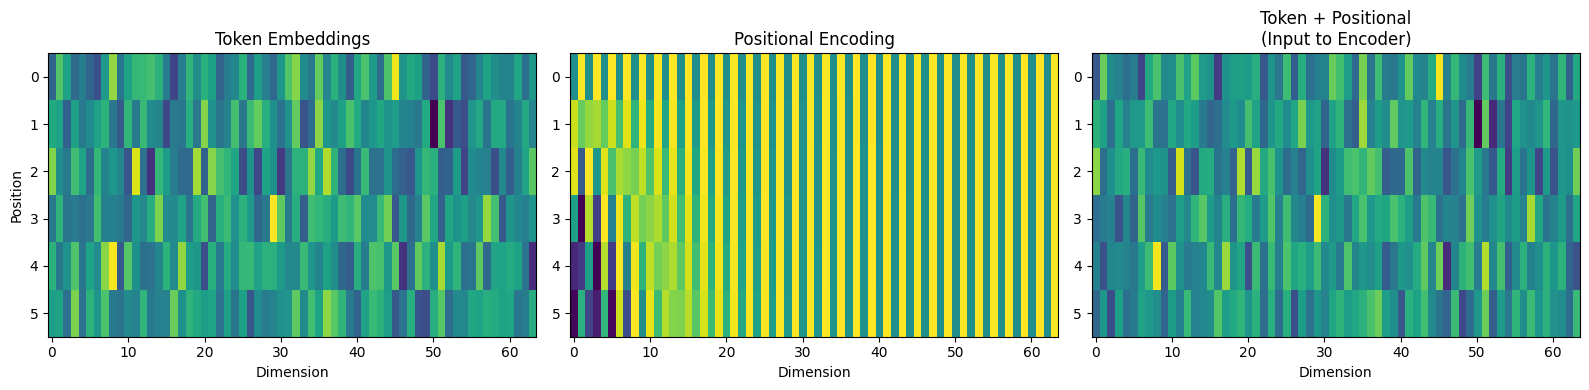

In [7]:
# Visualize: how token embedding vs. positional encoding vs. combined look
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sample = 0  # first sentence in batch

axes[0].imshow(tok_emb[sample].detach().numpy(), cmap='viridis', aspect='auto')
axes[0].set_title('Token Embeddings', fontsize=12)
axes[0].set_xlabel('Dimension')
axes[0].set_ylabel('Position')

pe_slice = pos_encoding.pe[0, :seq_len, :].numpy()
axes[1].imshow(pe_slice, cmap='viridis', aspect='auto')
axes[1].set_title('Positional Encoding', fontsize=12)
axes[1].set_xlabel('Dimension')

axes[2].imshow(embeddings[sample].detach().numpy(), cmap='viridis', aspect='auto')
axes[2].set_title('Token + Positional\n(Input to Encoder)', fontsize=12)
axes[2].set_xlabel('Dimension')

plt.tight_layout()
plt.show()

- The combined representation (right) feeds into the encoder — it carries both **what** the token is and **where** it appears

---

## 2. Layer Normalization

- **Layer normalization** normalizes the activations across the feature dimension for each individual example
- This stabilizes training and helps gradients flow better
- Unlike **batch normalization** (which normalizes across the batch), layer norm normalizes across the **features** of each single example

### 2.1 How Layer Norm works

For each token's embedding vector $x$, layer norm computes:

$$\text{LayerNorm}(x) = \gamma \cdot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$

Where:
- $\mu$ and $\sigma^2$ are the mean and variance computed across the feature dimension
- $\gamma$ (scale) and $\beta$ (shift) are learnable parameters
- $\epsilon$ is a small constant for numerical stability

In [8]:
class LayerNorm(nn.Module):
    """Layer Normalization (simplified implementation for understanding)."""
    
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(d_model))   # scale
        self.beta = nn.Parameter(torch.zeros(d_model))   # shift
        self.eps = eps
    
    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        mean = x.mean(dim=-1, keepdim=True)      # mean across features
        std = x.std(dim=-1, keepdim=True)         # std across features
        return self.gamma * (x - mean) / (std + self.eps) + self.beta

- Let's see layer norm in action and verify it matches PyTorch's built-in `nn.LayerNorm`

In [9]:
torch.manual_seed(42)

# Create sample data: 1 sentence, 4 tokens, 8-dim embeddings
x = torch.randn(1, 4, 8)
print("Input x (first token):")
print(x[0, 0])
print(f"  Mean: {x[0, 0].mean():.4f}")
print(f"  Std:  {x[0, 0].std():.4f}")

# Our implementation
our_ln = LayerNorm(8)
out_ours = our_ln(x)

# PyTorch's implementation
pt_ln = nn.LayerNorm(8)
out_pt = pt_ln(x)

print("\nAfter LayerNorm (first token):")
print(out_ours[0, 0].detach())
print(f"  Mean: {out_ours[0, 0].mean():.4f}")
print(f"  Std:  {out_ours[0, 0].std():.4f}")

Input x (first token):
tensor([ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784, -1.2345, -0.0431, -1.6047])
  Mean: 0.0007
  Std:  1.4991

After LayerNorm (first token):
tensor([ 1.2849,  0.9917,  0.6004, -1.4050,  0.4521, -0.8240, -0.0292, -1.0709])
  Mean: -0.0000
  Std:  1.0000


- After layer norm, each token's features have approximately **zero mean** and **unit variance**

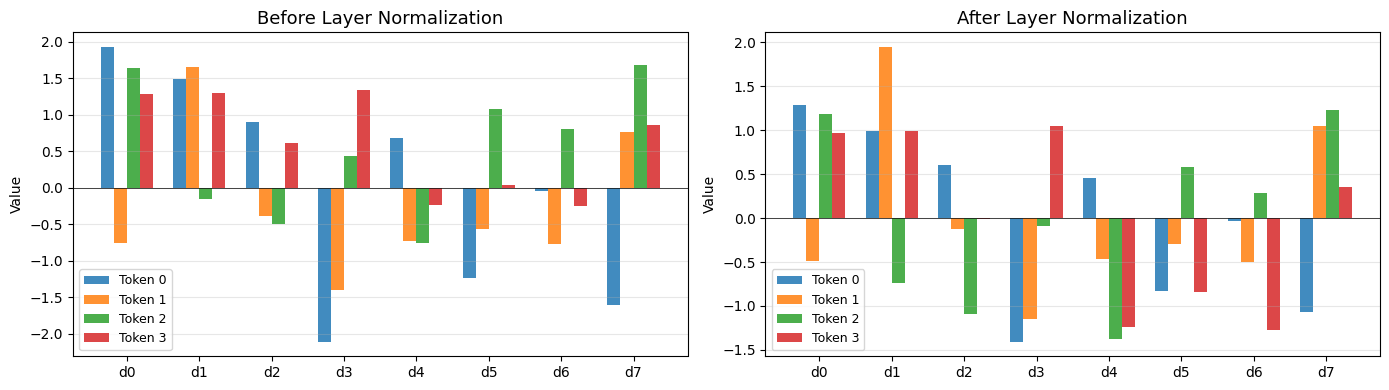

In [10]:
# Visualize: Before vs After Layer Norm
torch.manual_seed(42)
x = torch.randn(1, 4, 8)
ln = LayerNorm(8)
x_norm = ln(x).detach()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

token_labels = ['Token 0', 'Token 1', 'Token 2', 'Token 3']
dim_labels = [f'd{i}' for i in range(8)]
x_pos = np.arange(8)
width = 0.18

for i in range(4):
    axes[0].bar(x_pos + i * width, x[0, i].numpy(), width, label=token_labels[i], alpha=0.85)
axes[0].set_xticks(x_pos + 1.5 * width)
axes[0].set_xticklabels(dim_labels)
axes[0].set_title('Before Layer Normalization', fontsize=13)
axes[0].set_ylabel('Value')
axes[0].legend(fontsize=9)
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].grid(axis='y', alpha=0.3)

for i in range(4):
    axes[1].bar(x_pos + i * width, x_norm[0, i].numpy(), width, label=token_labels[i], alpha=0.85)
axes[1].set_xticks(x_pos + 1.5 * width)
axes[1].set_xticklabels(dim_labels)
axes[1].set_title('After Layer Normalization', fontsize=13)
axes[1].set_ylabel('Value')
axes[1].legend(fontsize=9)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

- After normalization, the values for each token are **centered** around 0 and have similar **spread**
- This prevents any single feature from dominating and helps the model train more stably

---

## 3. Multi-Head Self-Attention (Encoder version)

- In Chapter 2, we built multi-head attention with a **causal mask** (for GPT-style decoders)
- In the **encoder**, we use **bidirectional** attention — no masking! Every token can attend to every other token
- This is the key difference: the encoder sees the **full context** in both directions

In [11]:
class MultiHeadAttention(nn.Module):
    """Multi-Head Self-Attention for the Encoder (bidirectional, no causal mask)."""
    
    def __init__(self, d_model, num_heads, dropout=0.0):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        
        # Linear projections for Q, K, V
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        
        # Output projection
        self.W_o = nn.Linear(d_model, d_model)
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        batch_size, seq_len, d_model = x.shape
        
        # Step 1: Linear projections
        Q = self.W_q(x)  # (batch, seq_len, d_model)
        K = self.W_k(x)
        V = self.W_v(x)
        
        # Step 2: Reshape into multiple heads
        # (batch, seq_len, d_model) -> (batch, num_heads, seq_len, head_dim)
        Q = Q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        
        # Step 3: Scaled dot-product attention (NO causal mask!)
        attn_scores = Q @ K.transpose(-2, -1)  # (batch, heads, seq_len, seq_len)
        attn_scores = attn_scores / (self.head_dim ** 0.5)  # scale
        
        attn_weights = torch.softmax(attn_scores, dim=-1)  # normalize
        attn_weights = self.dropout(attn_weights)
        
        # Step 4: Weighted sum of values
        context = attn_weights @ V  # (batch, heads, seq_len, head_dim)
        
        # Step 5: Concatenate heads and project
        context = context.transpose(1, 2).contiguous()  # (batch, seq_len, num_heads, head_dim)
        context = context.view(batch_size, seq_len, d_model)  # (batch, seq_len, d_model)
        output = self.W_o(context)  # final linear projection
        
        return output, attn_weights

- Notice: **no causal mask** — unlike the decoder, the encoder allows full bidirectional attention
- We return both the output and the attention weights so we can visualize them

In [12]:
# Test our multi-head attention
torch.manual_seed(123)

d_model = 64
num_heads = 4
seq_len = 6

mha = MultiHeadAttention(d_model, num_heads)

# Use the embeddings from earlier
x = embeddings  # (batch=2, seq_len=6, d_model=64)
output, attn_weights = mha(x)

print("Input shape: ", x.shape)
print("Output shape:", output.shape)
print("Attention weights shape:", attn_weights.shape)
print(f"  -> {attn_weights.shape[1]} heads, each producing a {attn_weights.shape[2]}x{attn_weights.shape[3]} attention matrix")

Input shape:  torch.Size([2, 6, 64])
Output shape: torch.Size([2, 6, 64])
Attention weights shape: torch.Size([2, 4, 6, 6])
  -> 4 heads, each producing a 6x6 attention matrix


### 3.1 Visualizing Encoder Attention (Bidirectional)

- Let's compare **encoder attention** (bidirectional) vs **decoder attention** (causal/masked)
- In the encoder, every token can attend to every other token — no positions are blocked

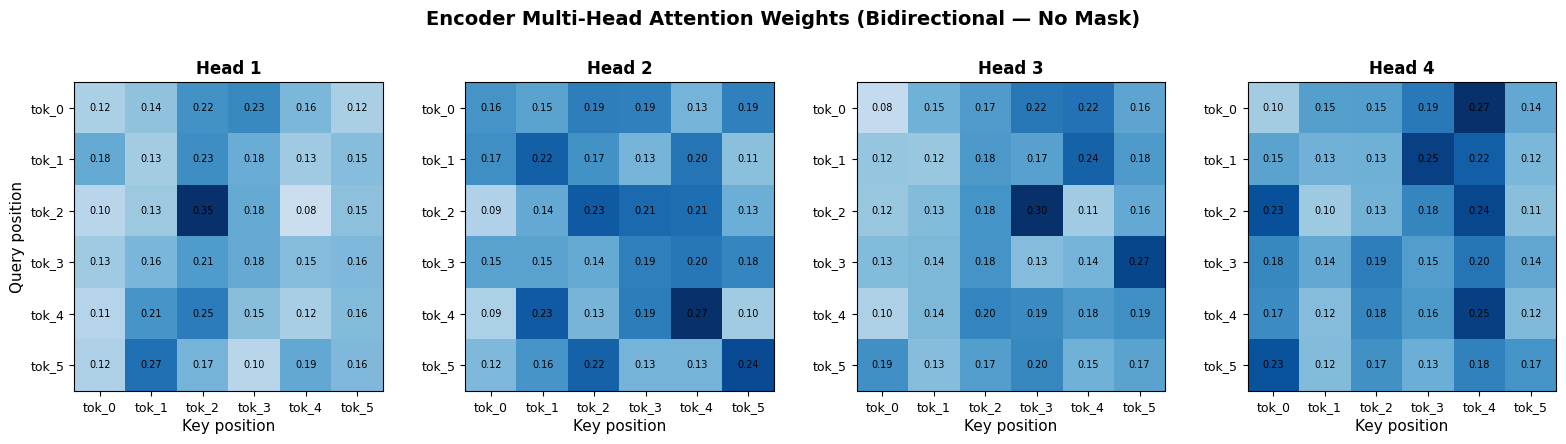

In [13]:
fig, axes = plt.subplots(1, num_heads, figsize=(16, 4))

token_labels = [f'tok_{i}' for i in range(seq_len)]

for head_idx in range(num_heads):
    ax = axes[head_idx]
    weights = attn_weights[0, head_idx].detach().numpy()  # first batch item
    
    im = ax.imshow(weights, cmap='Blues', vmin=0, vmax=weights.max())
    ax.set_title(f'Head {head_idx + 1}', fontsize=12, fontweight='bold')
    ax.set_xticks(range(seq_len))
    ax.set_yticks(range(seq_len))
    ax.set_xticklabels(token_labels, fontsize=9)
    ax.set_yticklabels(token_labels, fontsize=9)
    
    if head_idx == 0:
        ax.set_ylabel('Query position', fontsize=11)
    ax.set_xlabel('Key position', fontsize=11)
    
    # Add value annotations
    for i in range(seq_len):
        for j in range(seq_len):
            ax.text(j, i, f'{weights[i, j]:.2f}', ha='center', va='center', fontsize=7)

plt.suptitle('Encoder Multi-Head Attention Weights (Bidirectional — No Mask)', 
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

- Each head learns a **different attention pattern**
- All positions (rows) can attend to all other positions (columns) — this is the bidirectional nature of the encoder
- Compare this with decoder attention where the upper-right triangle would be zero (masked)

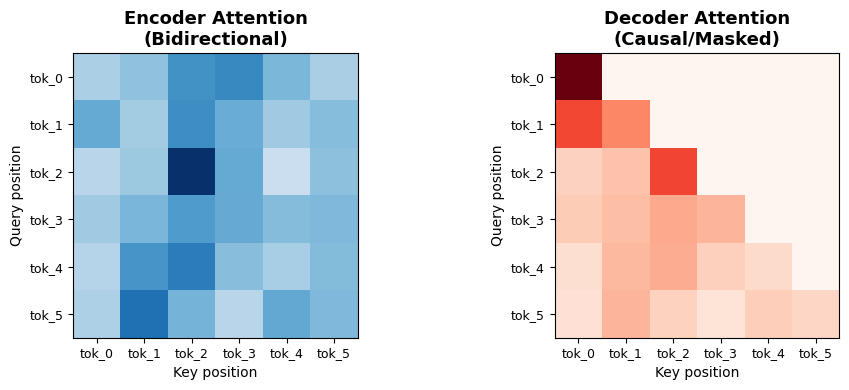

In [14]:
# Encoder vs Decoder attention comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Encoder: full attention (use first head from our MHA)
encoder_attn = attn_weights[0, 0].detach().numpy()
axes[0].imshow(encoder_attn, cmap='Blues', vmin=0)
axes[0].set_title('Encoder Attention\n(Bidirectional)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Key position')
axes[0].set_ylabel('Query position')

# Decoder: causal mask applied
causal_mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1)
masked_scores = attn_weights[0, 0].detach().clone()
masked_scores = masked_scores.masked_fill(causal_mask.bool(), 0.0)
# Re-normalize rows
row_sums = masked_scores.sum(dim=-1, keepdim=True)
decoder_attn = (masked_scores / row_sums).numpy()

axes[1].imshow(decoder_attn, cmap='Reds', vmin=0)
axes[1].set_title('Decoder Attention\n(Causal/Masked)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Key position')
axes[1].set_ylabel('Query position')

for ax in axes:
    ax.set_xticks(range(seq_len))
    ax.set_yticks(range(seq_len))
    ax.set_xticklabels(token_labels, fontsize=9)
    ax.set_yticklabels(token_labels, fontsize=9)

plt.tight_layout()
plt.show()

- **Left (Encoder)**: Full matrix — every token sees every other token
- **Right (Decoder)**: Upper triangle is zeroed out — token at position *i* can only see positions ≤ *i*
- This is the fundamental difference: the encoder builds **complete representations** of the input

---

## 4. Position-wise Feed-Forward Network (FFN)

- After the attention layer, each token's representation passes through a **feed-forward network**
- The FFN is applied to each position **independently** (the same network, different inputs)
- It consists of two linear transformations with a non-linearity (ReLU or GELU) in between:

$$\text{FFN}(x) = W_2 \cdot \text{ReLU}(W_1 \cdot x + b_1) + b_2$$

- The inner dimension (`d_ff`) is typically **4× larger** than `d_model` — this expansion/compression acts as a bottleneck that lets the model learn richer features

In [15]:
class FeedForward(nn.Module):
    """Position-wise Feed-Forward Network."""
    
    def __init__(self, d_model, d_ff, dropout=0.0):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)     # expand
        self.linear2 = nn.Linear(d_ff, d_model)      # compress back
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = self.linear1(x)   # (batch, seq_len, d_ff)
        x = self.relu(x)      # activation
        x = self.dropout(x)
        x = self.linear2(x)   # (batch, seq_len, d_model)
        return x

In [16]:
# Demonstrate the expand-compress pattern
d_model = 64
d_ff = 256  # 4x expansion

ffn = FeedForward(d_model, d_ff)

x = torch.randn(1, 6, d_model)  # 1 sentence, 6 tokens
out = ffn(x)

print(f"Input shape:  {x.shape}  (d_model = {d_model})")
print(f"Output shape: {out.shape}  (d_model = {d_model})")
print(f"\nInternally: {d_model} -> {d_ff} -> {d_model}")
print(f"Expansion factor: {d_ff // d_model}x")

Input shape:  torch.Size([1, 6, 64])  (d_model = 64)
Output shape: torch.Size([1, 6, 64])  (d_model = 64)

Internally: 64 -> 256 -> 64
Expansion factor: 4x


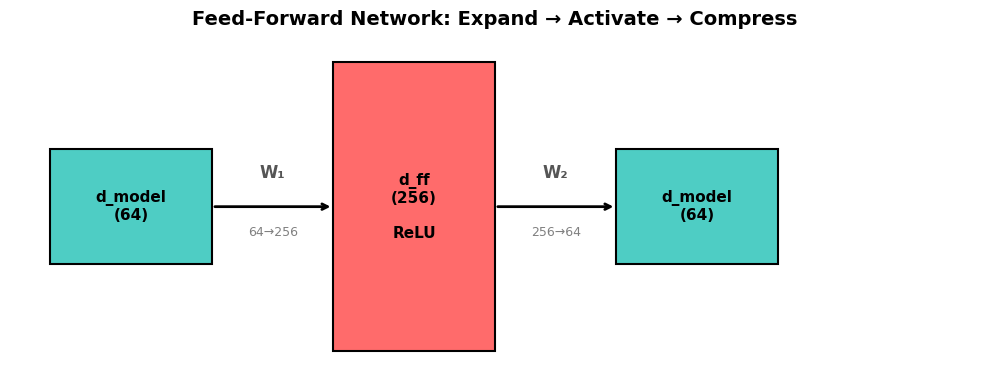

In [17]:
# Visualize the expand-compress bottleneck
fig, ax = plt.subplots(figsize=(10, 4))
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_title('Feed-Forward Network: Expand → Activate → Compress', fontsize=14, fontweight='bold')

# Input block
rect1 = plt.Rectangle((0.5, 2), 2, 2, facecolor='#4ECDC4', edgecolor='black', linewidth=1.5)
ax.add_patch(rect1)
ax.text(1.5, 3, f'd_model\n({d_model})', ha='center', va='center', fontsize=11, fontweight='bold')

# Expanded block
rect2 = plt.Rectangle((4, 0.5), 2, 5, facecolor='#FF6B6B', edgecolor='black', linewidth=1.5)
ax.add_patch(rect2)
ax.text(5, 3, f'd_ff\n({d_ff})\n\nReLU', ha='center', va='center', fontsize=11, fontweight='bold')

# Output block
rect3 = plt.Rectangle((7.5, 2), 2, 2, facecolor='#4ECDC4', edgecolor='black', linewidth=1.5)
ax.add_patch(rect3)
ax.text(8.5, 3, f'd_model\n({d_model})', ha='center', va='center', fontsize=11, fontweight='bold')

# Arrows
ax.annotate('', xy=(4, 3), xytext=(2.5, 3), arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax.annotate('', xy=(7.5, 3), xytext=(6, 3), arrowprops=dict(arrowstyle='->', lw=2, color='black'))

ax.text(3.25, 3.5, 'W₁', fontsize=12, ha='center', fontweight='bold', color='#555')
ax.text(6.75, 3.5, 'W₂', fontsize=12, ha='center', fontweight='bold', color='#555')

ax.text(3.25, 2.5, f'{d_model}→{d_ff}', fontsize=9, ha='center', color='gray')
ax.text(6.75, 2.5, f'{d_ff}→{d_model}', fontsize=9, ha='center', color='gray')

plt.tight_layout()
plt.show()

- The FFN expands the representation to a higher dimension, applies a non-linearity, then compresses back
- Think of it as: "take a wider look at the features, then distill back to the original size"
- The ReLU activation introduces **non-linearity**, which is essential for learning complex patterns

---

## 5. Residual Connections

- A **residual connection** (or skip connection) adds the input of a sub-layer to its output:

$$\text{output} = \text{SubLayer}(x) + x$$

- This helps with:
  - **Gradient flow**: gradients can bypass layers via the shortcut, preventing vanishing gradients
  - **Training stability**: the model can learn to make sub-layers "do nothing" if needed (identity mapping)
  - **Deeper networks**: without residual connections, training very deep transformers would fail

In [18]:
# Simple demonstration of residual connections
torch.manual_seed(42)

x = torch.randn(1, 4, 8)  # input

# Simulate a sub-layer (just a linear transformation here)
sublayer = nn.Linear(8, 8)
sublayer_output = sublayer(x)

# Without residual
output_no_residual = sublayer_output

# With residual
output_with_residual = sublayer_output + x  # <-- this is the residual connection!

print("Input (first token):          ", x[0, 0].detach().numpy().round(3))
print("SubLayer output (first token): ", sublayer_output[0, 0].detach().numpy().round(3))
print("With residual (first token):   ", output_with_residual[0, 0].detach().numpy().round(3))

Input (first token):           [ 1.927  1.487  0.901 -2.106  0.678 -1.235 -0.043 -1.605]
SubLayer output (first token):  [ 0.236 -0.39  -0.909  1.146  0.517 -0.239  0.394 -0.023]
With residual (first token):    [ 2.163  1.097 -0.008 -0.959  1.195 -1.473  0.351 -1.628]


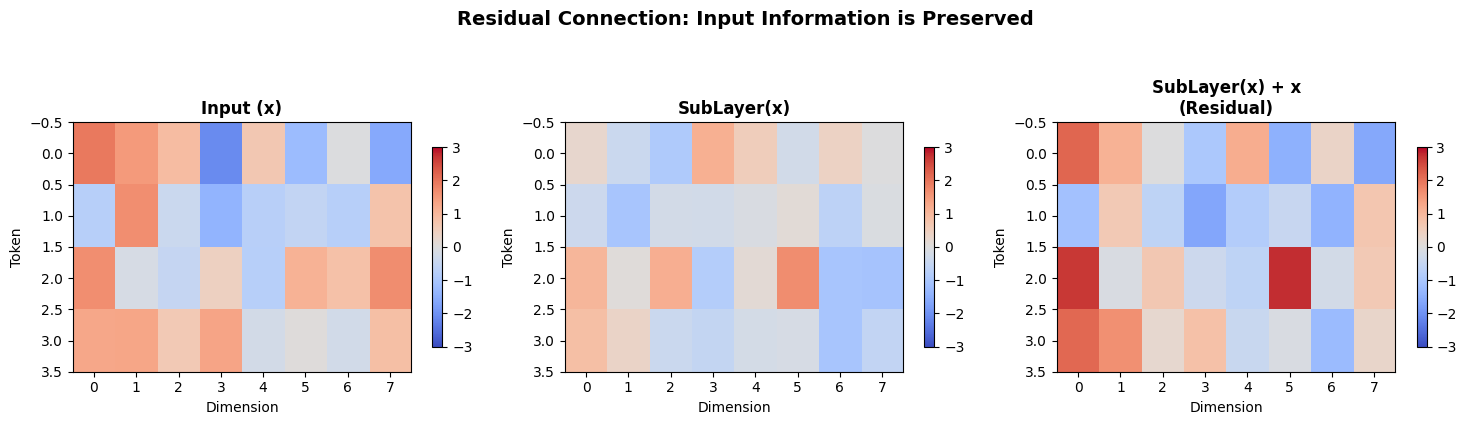

In [19]:
# Visualize how residual connections preserve information
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

data = [
    (x[0].detach().numpy(), 'Input (x)', '#4ECDC4'),
    (sublayer_output[0].detach().numpy(), 'SubLayer(x)', '#FF6B6B'),
    (output_with_residual[0].detach().numpy(), 'SubLayer(x) + x\n(Residual)', '#95E1D3'),
]

for ax, (vals, title, color) in zip(axes, data):
    im = ax.imshow(vals, cmap='coolwarm', aspect='auto', vmin=-3, vmax=3)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Dimension')
    ax.set_ylabel('Token')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Residual Connection: Input Information is Preserved', 
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

- The residual output (right) keeps both the original input pattern and the learned transformation
- If the sub-layer learns to output zeros, the residual connection simply passes the input through unchanged — a safe default

---

## 6. Putting It Together: The Encoder Block

- Now we combine all the building blocks into a single **Encoder Block**
- Each block has this structure:

```
Input
  │
  ├──────────────────────┐
  ▼                      │ (residual)
  Multi-Head Attention   │
  ▼                      │
  Add ◄──────────────────┘
  ▼
  Layer Norm
  │
  ├──────────────────────┐
  ▼                      │ (residual)
  Feed-Forward Network   │
  ▼                      │
  Add ◄──────────────────┘
  ▼
  Layer Norm
  │
  ▼
Output
```

In [20]:
class EncoderBlock(nn.Module):
    """A single Transformer Encoder Block."""
    
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        
        # Sub-layer 1: Multi-Head Self-Attention
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        
        # Sub-layer 2: Feed-Forward Network
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout2 = nn.Dropout(dropout)
    
    def forward(self, x):
        # Sub-layer 1: Attention + Residual + Norm
        attn_output, attn_weights = self.self_attn(x)
        x = self.norm1(x + self.dropout1(attn_output))  # residual + layer norm
        
        # Sub-layer 2: FFN + Residual + Norm
        ffn_output = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_output))   # residual + layer norm
        
        return x, attn_weights

In [21]:
# Test the encoder block
torch.manual_seed(123)

d_model = 64
num_heads = 4
d_ff = 256
seq_len = 6
batch_size = 2

encoder_block = EncoderBlock(d_model, num_heads, d_ff, dropout=0.1)
encoder_block.eval()  # disable dropout for testing

# Use our embeddings as input
x = embeddings  # (2, 6, 64)
out, attn_w = encoder_block(x)

print(f"Input shape:  {x.shape}")
print(f"Output shape: {out.shape}")
print("\n-> Same shape! The encoder block transforms representations without changing dimensions")

Input shape:  torch.Size([2, 6, 64])
Output shape: torch.Size([2, 6, 64])

-> Same shape! The encoder block transforms representations without changing dimensions


### 6.1 Visualizing data flow through the Encoder Block

- Let's trace what happens to our data at each stage inside the encoder block

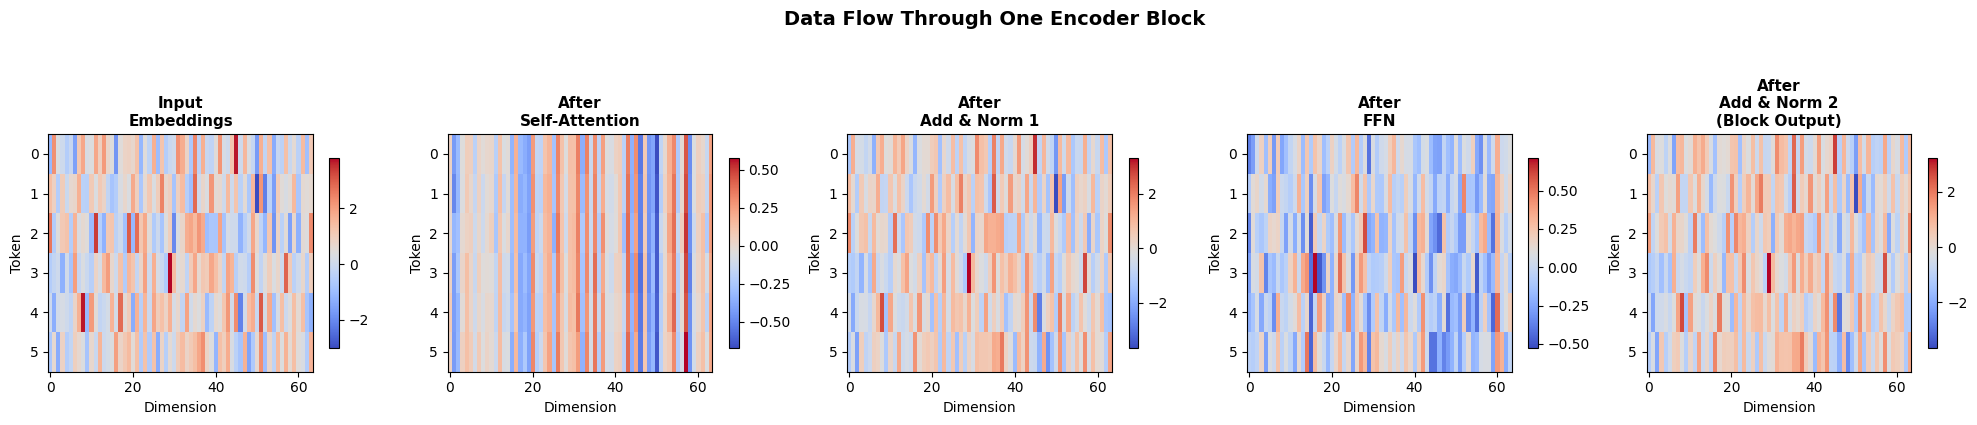

In [22]:
# Trace the data flow step by step
torch.manual_seed(123)
encoder_block = EncoderBlock(d_model, num_heads, d_ff, dropout=0.0)
encoder_block.eval()

x_input = embeddings.detach().clone()

# Step 1: Self-Attention
attn_out, attn_w = encoder_block.self_attn(x_input)

# Step 2: Residual + LayerNorm (after attention)
after_add_norm1 = encoder_block.norm1(x_input + attn_out)

# Step 3: FFN
ffn_out = encoder_block.ffn(after_add_norm1)

# Step 4: Residual + LayerNorm (after FFN)
after_add_norm2 = encoder_block.norm2(after_add_norm1 + ffn_out)

# Visualize each stage
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

stages = [
    (x_input[0], 'Input\nEmbeddings'),
    (attn_out[0], 'After\nSelf-Attention'),
    (after_add_norm1[0], 'After\nAdd & Norm 1'),
    (ffn_out[0], 'After\nFFN'),
    (after_add_norm2[0], 'After\nAdd & Norm 2\n(Block Output)'),
]

for ax, (tensor, title) in zip(axes, stages):
    im = ax.imshow(tensor.detach().numpy(), cmap='coolwarm', aspect='auto')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Dimension')
    ax.set_ylabel('Token')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Data Flow Through One Encoder Block', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

- Each stage transforms the representations while maintaining the same shape
- The Add & Norm steps keep the values well-behaved (notice the more uniform scale after normalization)

---

## 7. The Full Transformer Encoder

- The full encoder is a **stack of N identical Encoder Blocks**
- The original Transformer uses N=6 blocks
- BERT-base uses N=12, BERT-large uses N=24
- Each block refines the representations further, building increasingly abstract features

In [23]:
class TransformerEncoder(nn.Module):
    """Full Transformer Encoder: Embedding + Positional Encoding + N Encoder Blocks."""
    
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers, 
                 max_len=512, dropout=0.1):
        super().__init__()
        
        # Input processing
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = SinusoidalPositionalEncoding(d_model, max_len)
        self.dropout = nn.Dropout(dropout)
        
        # Stack of encoder blocks
        self.layers = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        
        # Final layer norm
        self.norm = nn.LayerNorm(d_model)
        
        # Scale embeddings (as in the original paper)
        self.d_model = d_model
    
    def forward(self, x):
        # x shape: (batch_size, seq_len) — token IDs
        
        # Step 1: Token embedding (scaled) + positional encoding
        x = self.token_embedding(x) * (self.d_model ** 0.5)  # scale by sqrt(d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        
        # Step 2: Pass through N encoder blocks
        all_attn_weights = []
        for layer in self.layers:
            x, attn_weights = layer(x)
            all_attn_weights.append(attn_weights)
        
        # Step 3: Final layer norm
        x = self.norm(x)
        
        return x, all_attn_weights

In [24]:
# Create a Transformer Encoder with the original paper's configuration (scaled down)
torch.manual_seed(123)

# Hyperparameters (scaled-down version for demonstration)
VOCAB_SIZE = 1000
D_MODEL = 64       # embedding dimension (original: 512)
NUM_HEADS = 4      # number of attention heads (original: 8)
D_FF = 256          # feed-forward dimension (original: 2048)
NUM_LAYERS = 4      # number of encoder blocks (original: 6)
MAX_LEN = 128
DROPOUT = 0.1

encoder = TransformerEncoder(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    num_layers=NUM_LAYERS,
    max_len=MAX_LEN,
    dropout=DROPOUT
)

# Count parameters
total_params = sum(p.numel() for p in encoder.parameters())
trainable_params = sum(p.numel() for p in encoder.parameters() if p.requires_grad)

print(f"Transformer Encoder created!")
print(f"  Layers: {NUM_LAYERS}")
print(f"  d_model: {D_MODEL}")
print(f"  Heads: {NUM_HEADS}")
print(f"  d_ff: {D_FF}")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

Transformer Encoder created!
  Layers: 4
  d_model: 64
  Heads: 4
  d_ff: 256
  Total parameters: 264,064
  Trainable parameters: 264,064


In [25]:
# Forward pass
encoder.eval()

input_ids = torch.tensor([
    [10, 23, 45, 67, 89, 12],
    [5,  33, 78, 90, 11, 42]
])

with torch.no_grad():
    output, all_attn_weights = encoder(input_ids)

print(f"Input shape:  {input_ids.shape}  (batch=2, seq_len=6)")
print(f"Output shape: {output.shape}  (batch=2, seq_len=6, d_model={D_MODEL})")
print(f"\nNumber of attention weight matrices: {len(all_attn_weights)} (one per layer)")
print(f"Each attention weight shape: {all_attn_weights[0].shape}")

Input shape:  torch.Size([2, 6])  (batch=2, seq_len=6)
Output shape: torch.Size([2, 6, 64])  (batch=2, seq_len=6, d_model=64)

Number of attention weight matrices: 4 (one per layer)
Each attention weight shape: torch.Size([2, 4, 6, 6])


### 7.1 Visualizing Attention Across All Layers

- Let's see how attention patterns change as data flows through the encoder layers
- Earlier layers often learn local patterns; deeper layers learn more global relationships

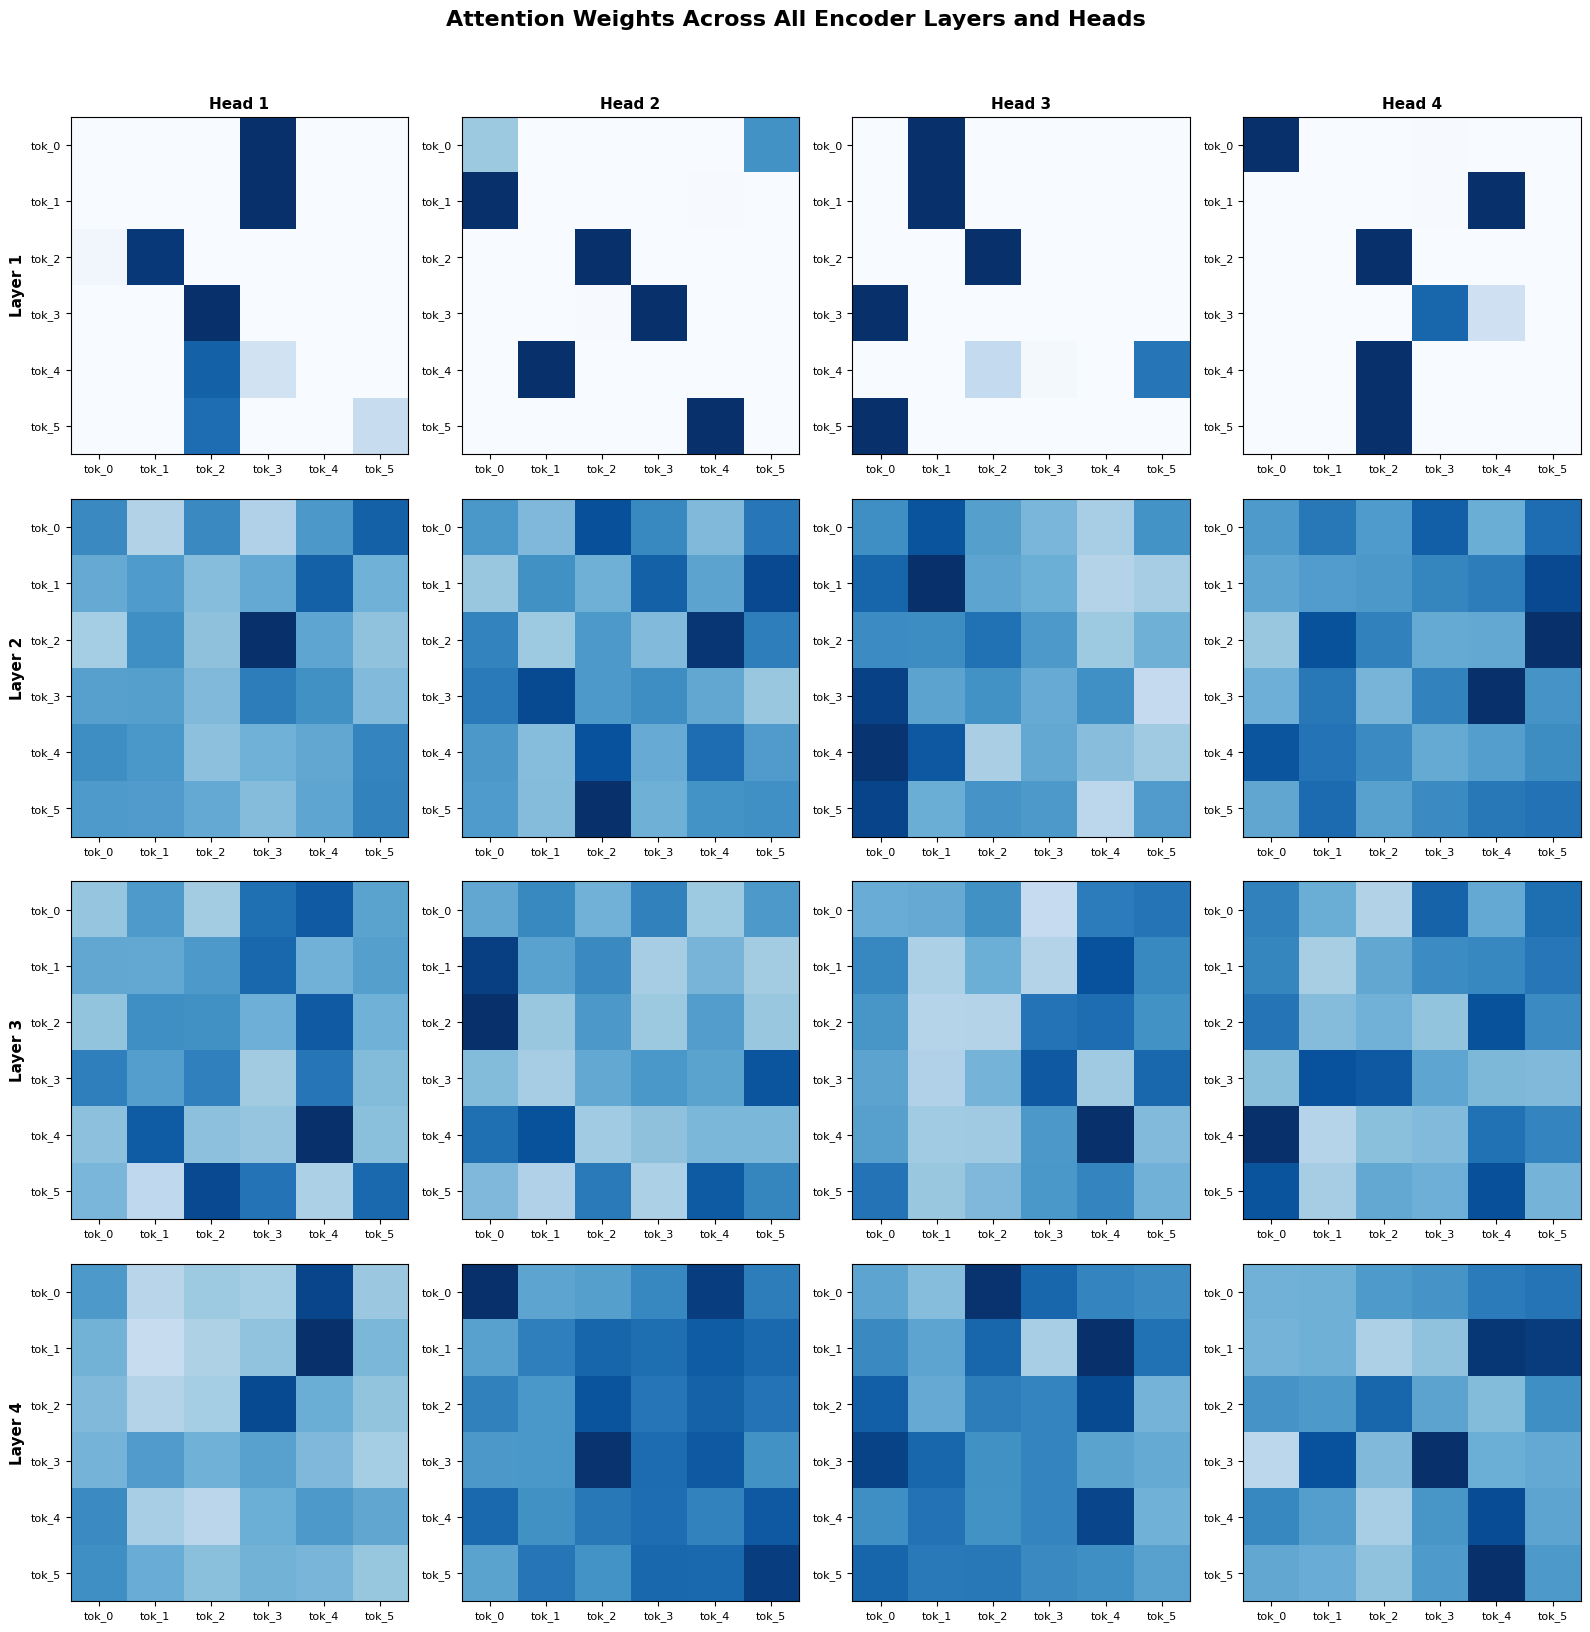

In [26]:
fig, axes = plt.subplots(NUM_LAYERS, NUM_HEADS, figsize=(16, 4 * NUM_LAYERS))

token_labels = [f'tok_{i}' for i in range(seq_len)]

for layer_idx in range(NUM_LAYERS):
    for head_idx in range(NUM_HEADS):
        ax = axes[layer_idx, head_idx]
        weights = all_attn_weights[layer_idx][0, head_idx].detach().numpy()
        
        im = ax.imshow(weights, cmap='Blues', vmin=0, vmax=weights.max())
        
        if layer_idx == 0:
            ax.set_title(f'Head {head_idx + 1}', fontsize=11, fontweight='bold')
        if head_idx == 0:
            ax.set_ylabel(f'Layer {layer_idx + 1}', fontsize=11, fontweight='bold')
        
        ax.set_xticks(range(seq_len))
        ax.set_yticks(range(seq_len))
        ax.set_xticklabels(token_labels, fontsize=8)
        ax.set_yticklabels(token_labels, fontsize=8)

plt.suptitle('Attention Weights Across All Encoder Layers and Heads', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

- Each layer and head captures **different patterns** of token relationships
- Some heads may specialize in attending to nearby tokens, others to distant ones
- Deeper layers build on the refined representations from earlier layers

### 7.2 Parameter Distribution

- Let's see where the parameters live in our encoder

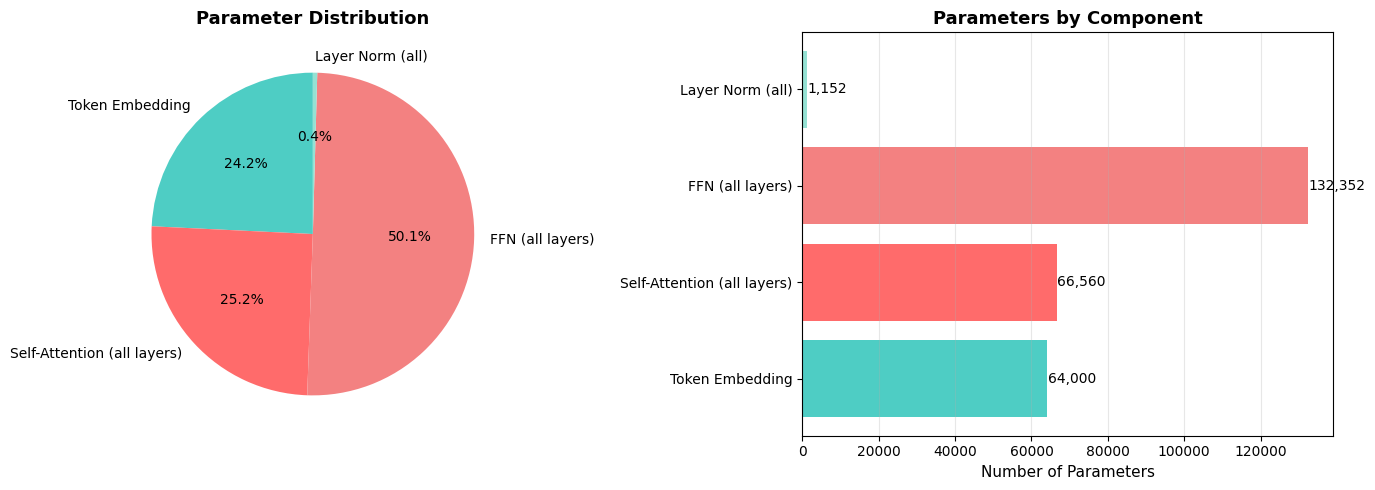

In [27]:
# Count parameters by component
param_counts = {}
param_counts['Token Embedding'] = sum(p.numel() for p in encoder.token_embedding.parameters())

attn_params = 0
ffn_params = 0
norm_params = 0
for layer in encoder.layers:
    attn_params += sum(p.numel() for p in layer.self_attn.parameters())
    ffn_params += sum(p.numel() for p in layer.ffn.parameters())
    norm_params += sum(p.numel() for p in layer.norm1.parameters())
    norm_params += sum(p.numel() for p in layer.norm2.parameters())

norm_params += sum(p.numel() for p in encoder.norm.parameters())

param_counts['Self-Attention (all layers)'] = attn_params
param_counts['FFN (all layers)'] = ffn_params
param_counts['Layer Norm (all)'] = norm_params

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors_pie = ['#4ECDC4', '#FF6B6B', '#F38181', '#95E1D3']
labels = list(param_counts.keys())
sizes = list(param_counts.values())

axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors_pie, 
            startangle=90, textprops={'fontsize': 10})
axes[0].set_title('Parameter Distribution', fontsize=13, fontweight='bold')

# Bar chart
bars = axes[1].barh(labels, sizes, color=colors_pie)
axes[1].set_xlabel('Number of Parameters', fontsize=11)
axes[1].set_title('Parameters by Component', fontsize=13, fontweight='bold')
for bar, size in zip(bars, sizes):
    axes[1].text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2, 
                f'{size:,}', va='center', fontsize=10)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

- The **FFN layers** typically have the most parameters because of the 4x expansion
- **Self-Attention** has the Q, K, V, and output projection matrices
- **Layer Norm** has very few parameters (just scale and shift per dimension)
- The **embedding table** size depends on vocabulary size

---

## 8. Encoder in Action: A Complete Example

- Let's run a complete example from raw token IDs through the full encoder
- We'll trace the shape and values at every step

In [28]:
torch.manual_seed(42)

# Create a fresh encoder
encoder_demo = TransformerEncoder(
    vocab_size=1000, d_model=32, num_heads=4, d_ff=128,
    num_layers=3, max_len=64, dropout=0.0
)
encoder_demo.eval()

# Input: a batch of 1 sentence with 5 tokens
tokens = torch.tensor([[42, 100, 7, 256, 88]])

print("=" * 60)
print("STEP-BY-STEP FORWARD PASS")
print("=" * 60)

# Step 1: Token embedding
tok_emb = encoder_demo.token_embedding(tokens) * (32 ** 0.5)
print(f"\n1. Token Embedding:  {tokens.shape} -> {tok_emb.shape}")
print(f"   (token IDs -> dense vectors, scaled by sqrt(d_model))")

# Step 2: Add positional encoding
with_pos = encoder_demo.pos_encoding(tok_emb)
print(f"\n2. + Positional Enc: {tok_emb.shape} -> {with_pos.shape}")
print(f"   (added sinusoidal position info)")

# Step 3: Through each encoder layer
x = with_pos
for i, layer in enumerate(encoder_demo.layers):
    x, attn_w = layer(x)
    print(f"\n3.{i+1} Encoder Block {i+1}: {with_pos.shape} -> {x.shape}")
    print(f"    Attention weights: {attn_w.shape}")

# Step 4: Final layer norm
output = encoder_demo.norm(x)
print(f"\n4. Final LayerNorm:  {x.shape} -> {output.shape}")
print(f"\n" + "=" * 60)
print(f"Final output: {output.shape}")
print(f"Each of the 5 tokens now has a {output.shape[-1]}-dim contextualized representation")
print("=" * 60)

STEP-BY-STEP FORWARD PASS

1. Token Embedding:  torch.Size([1, 5]) -> torch.Size([1, 5, 32])
   (token IDs -> dense vectors, scaled by sqrt(d_model))

2. + Positional Enc: torch.Size([1, 5, 32]) -> torch.Size([1, 5, 32])
   (added sinusoidal position info)

3.1 Encoder Block 1: torch.Size([1, 5, 32]) -> torch.Size([1, 5, 32])
    Attention weights: torch.Size([1, 4, 5, 5])

3.2 Encoder Block 2: torch.Size([1, 5, 32]) -> torch.Size([1, 5, 32])
    Attention weights: torch.Size([1, 4, 5, 5])

3.3 Encoder Block 3: torch.Size([1, 5, 32]) -> torch.Size([1, 5, 32])
    Attention weights: torch.Size([1, 4, 5, 5])

4. Final LayerNorm:  torch.Size([1, 5, 32]) -> torch.Size([1, 5, 32])

Final output: torch.Size([1, 5, 32])
Each of the 5 tokens now has a 32-dim contextualized representation


### 8.1 How representations evolve through layers

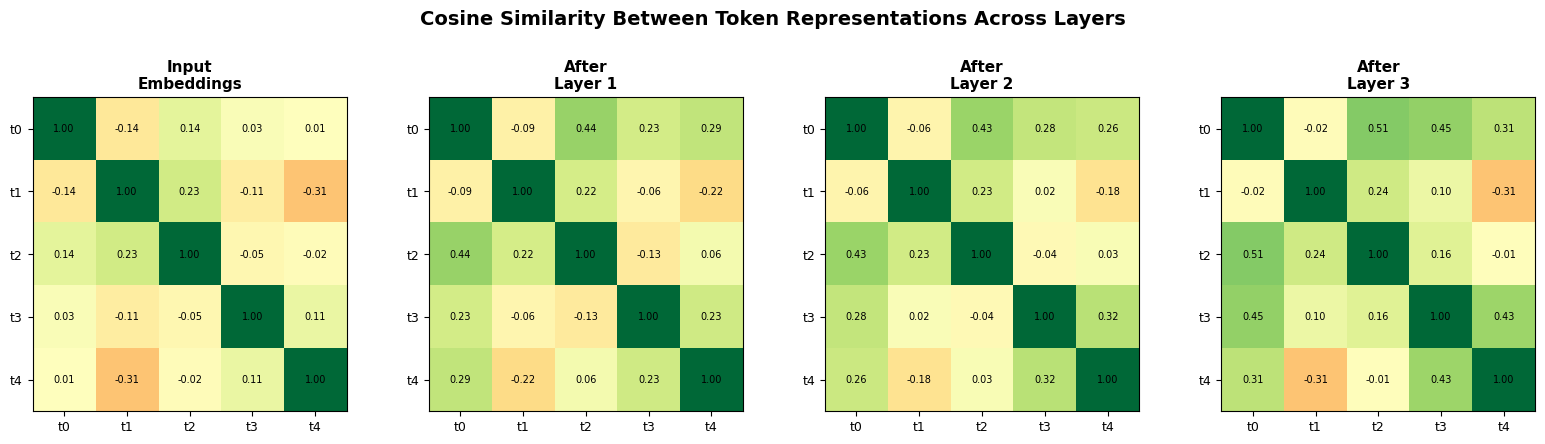

In [29]:
# Collect intermediate representations
torch.manual_seed(42)
encoder_demo.eval()

tokens = torch.tensor([[42, 100, 7, 256, 88]])

# Get embeddings
x = encoder_demo.token_embedding(tokens) * (32 ** 0.5)
x = encoder_demo.pos_encoding(x)

layer_outputs = [x.detach().clone()]
for layer in encoder_demo.layers:
    x, _ = layer(x)
    layer_outputs.append(x.detach().clone())

# Compute cosine similarity between token pairs at each layer
num_tokens = 5
num_stages = len(layer_outputs)

fig, axes = plt.subplots(1, num_stages, figsize=(4 * num_stages, 4))

stage_names = ['Input\nEmbeddings'] + [f'After\nLayer {i+1}' for i in range(num_stages - 1)]

for idx, (layer_out, name) in enumerate(zip(layer_outputs, stage_names)):
    # Compute cosine similarity matrix
    normed = layer_out[0] / layer_out[0].norm(dim=-1, keepdim=True)
    cos_sim = (normed @ normed.T).numpy()
    
    im = axes[idx].imshow(cos_sim, cmap='RdYlGn', vmin=-1, vmax=1)
    axes[idx].set_title(name, fontsize=11, fontweight='bold')
    axes[idx].set_xticks(range(num_tokens))
    axes[idx].set_yticks(range(num_tokens))
    axes[idx].set_xticklabels([f't{i}' for i in range(num_tokens)], fontsize=9)
    axes[idx].set_yticklabels([f't{i}' for i in range(num_tokens)], fontsize=9)
    
    for i in range(num_tokens):
        for j in range(num_tokens):
            axes[idx].text(j, i, f'{cos_sim[i, j]:.2f}', ha='center', va='center', fontsize=7)

plt.suptitle('Cosine Similarity Between Token Representations Across Layers',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

- This shows how token representations **evolve** as they pass through encoder layers
- Initially, token representations may be quite different from each other
- As information flows through the attention mechanism, tokens that are relevant to each other become more similar
- The encoder is building **contextualized** representations — the same word in different contexts gets different representations

---

## 9. Summary: The Complete Encoder Architecture

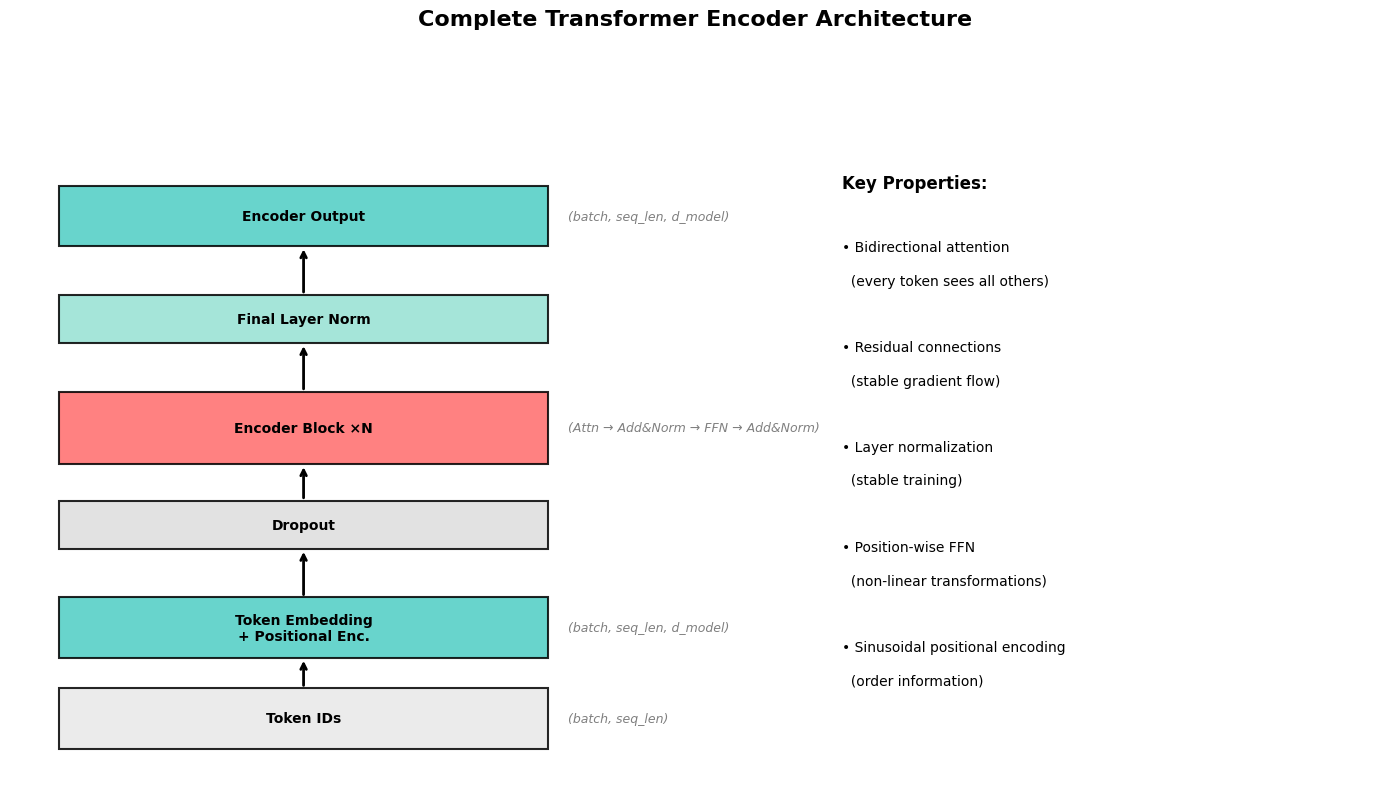

In [30]:
# Final architecture summary visualization
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 12)
ax.axis('off')
ax.set_title('Complete Transformer Encoder Architecture', fontsize=16, fontweight='bold', pad=20)

# Left side: Architecture diagram
blocks = [
    (0.5, 0.5, 5, 1.0, 'Token IDs', '#E8E8E8', '(batch, seq_len)'),
    (0.5, 2.0, 5, 1.0, 'Token Embedding\n+ Positional Enc.', '#4ECDC4', '(batch, seq_len, d_model)'),
    (0.5, 3.8, 5, 0.8, 'Dropout', '#DDD', ''),
    (0.5, 5.2, 5, 1.2, 'Encoder Block ×N', '#FF6B6B', '(Attn → Add&Norm → FFN → Add&Norm)'),
    (0.5, 7.2, 5, 0.8, 'Final Layer Norm', '#95E1D3', ''),
    (0.5, 8.8, 5, 1.0, 'Encoder Output', '#4ECDC4', '(batch, seq_len, d_model)'),
]

for x, y, w, h, label, color, shape_text in blocks:
    rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor='black', linewidth=1.5, alpha=0.85)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=10, fontweight='bold')
    if shape_text:
        ax.text(x + w + 0.2, y + h/2, shape_text, ha='left', va='center', fontsize=9, 
                color='gray', fontstyle='italic')

# Arrows
for y_start, y_end in [(1.5, 2.0), (3.0, 3.8), (4.6, 5.2), (6.4, 7.2), (8.0, 8.8)]:
    ax.annotate('', xy=(3, y_end), xytext=(3, y_start),
                arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# Right side: Key properties
props = [
    'Key Properties:',
    '',
    '• Bidirectional attention',
    '  (every token sees all others)',
    '',
    '• Residual connections',
    '  (stable gradient flow)',
    '',
    '• Layer normalization',
    '  (stable training)',
    '',
    '• Position-wise FFN',
    '  (non-linear transformations)',
    '',
    '• Sinusoidal positional encoding',
    '  (order information)',
]

for i, text in enumerate(props):
    weight = 'bold' if i == 0 else 'normal'
    size = 12 if i == 0 else 10
    ax.text(8.5, 10 - i * 0.55, text, fontsize=size, fontweight=weight, va='top')

plt.tight_layout()
plt.show()

### Key Takeaways

- The **Transformer Encoder** transforms a sequence of token IDs into **contextualized representations**
- It is built from simple, composable building blocks:
  1. **Embeddings + Positional Encoding**: Give tokens both meaning and position
  2. **Multi-Head Self-Attention**: Let tokens communicate bidirectionally
  3. **Feed-Forward Network**: Apply non-linear transformations per position
  4. **Residual Connections**: Enable gradient flow and stable training
  5. **Layer Normalization**: Keep activations well-behaved
- These blocks are stacked N times, with each layer refining the representations
- The encoder is used in models like **BERT** (for classification, NER, QA) and in the encoder part of **seq-to-seq** models like **T5**

In [31]:
# Print the full model architecture
print(encoder)

TransformerEncoder(
  (token_embedding): Embedding(1000, 64)
  (pos_encoding): SinusoidalPositionalEncoding()
  (dropout): Dropout(p=0.1, inplace=False)
  (layers): ModuleList(
    (0): EncoderBlock(
      (self_attn): MultiHeadAttention(
        (W_q): Linear(in_features=64, out_features=64, bias=True)
        (W_k): Linear(in_features=64, out_features=64, bias=True)
        (W_v): Linear(in_features=64, out_features=64, bias=True)
        (W_o): Linear(in_features=64, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout1): Dropout(p=0.1, inplace=False)
      (ffn): FeedForward(
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (relu): ReLU()
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (d

### Comparison: Original Transformer Encoder vs Our Implementation

| Component | Original Paper | Our Implementation |
|-----------|---------------|--------------------|
| d_model | 512 | 64 |
| num_heads | 8 | 4 |
| d_ff | 2048 | 256 |
| num_layers | 6 | 4 |
| Positional Encoding | Sinusoidal | Sinusoidal |
| Attention | Bidirectional | Bidirectional |
| Normalization | Post-norm | Post-norm |
| Dropout | 0.1 | 0.1 |

- Our implementation follows the **exact same architecture** as the original, just with smaller dimensions for demonstration purposes
- To scale up, simply increase the hyperparameters!